In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import xarray as xr 

# Notebook dedicated to finding the density field of Norkyst and considering density distributions for ML training

**Think we have to use GSW because seawater uses practical salinity - not absolute salinity as the GSW module**

Will therefore be testing the GSW first

The GSW functions for calculating the density needs the following inputs: (Absolute Salinity \& Conserved Temperature \& Absolute Sea Pressure)

We will therefore need to calculate the conserved temperature also, which is done by using: gsw.CT_from_t, which needs: Absolute Salinity, in-situ temperatures and sea pressure. However, I will use calculated temperature, not in-situ observations. I will also use the GSW functions to calculate the pressure, based on the ocean depth for the rho density function - but this is needed for the $\sigma_0$ function. 

**It is:** --> gsw_p_from_z(z, latitude, geo_strf_dyn_height, sea_surface_geopotential)

# Mathematical equations

The **main equation** used is: 

$$
\hat{v} (S_A \Theta, p ) = v_u \sum_{i,j,k} v_{ijk} s^i \tau^j \pi^k 
$$

Where the values associated with i,j,k are given in the TEOS10 manual in Appendix K. 

$$
s = \sqrt{\frac{S_A + 24 gkg^-1}{S_{A_u}}}, \quad S_{A_u} = \frac{40 \times 35.16504 g kg^{-1}}{35}
$$

$$
\tau = \frac{\Theta}{\Theta_u}, \quad \Theta_u = 40^{\circ} C  
$$

$$
\pi = \frac{p}{p_u}, \quad P_u = 10^4 dbar
$$

$$
v_u = 1m^{3} kg^{-1}, \quad 
$$

However, p = 0 in this function and therefore $\pi \rightarrow 0$ when $k > 0$. Thats why the GSW function only needs salinity and temperature, not pressure for calculating the surface density: 

$$\hat{v} (S_A, \Theta, p = 0)$$


**Furthermore**, we also need to calculate the conserved temperature to use in the main equation. The following related equations are dedicated to this process.

For calculating the conserved temperature, we need to calculate both the entropy and a potential entalpi! The following steps are therefore needed in the calculations:

1. Calculation of the entropy (equation 2.10.1 from the TEOS manual): 

$$
\eta = \eta(S_A, t, p) = -g_T = - \frac{\partial g_T}{\partial T}
$$

In TEOS - empirical values are already used to create polynomial functions of $\eta$ - and I will rather use these estimated values directly with the aimn to reduce the need for computational calculations. These approximated values are found in appendix B of the TEOS and Copernicus manual! https://os.copernicus.org/articles/19/1719/2023/os-19-1719-2023.pdf

2. An iterativ calculation of potential temperature for the surface - ie. $\theta_0$. This is calculated using the Newton-Raphson iterative technique as illustrated in the equation below, found from TEOS10. It can also be estimated as an integral of the adiabatic lapse rate (Fofonoff, 1962 \& 1985), but I also suspect this would require potentially unneseccary computational power. 

$$
\eta (S_A, \theta, p_r) = \eta (S_A, t, p)
$$

The Newton Raphson iterative process is:
$$
x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}
$$

Where we have to differentiate $g_t$ in our calculations.

$$
\begin{align}
& \frac{\partial}{\partial \tau} (c_{i,j} \cdot s^i \cdot \tau^j) \\
& (j \cdot c_{i,j} \cdot s^i \cdot tau^{j -1})'
\end{align}
$$

 Furthermore, the full thermodynamic equation of entropy is given as: 

$$
\hat{\eta} (S_A, \Theta) = c_p^0 ln(1 + \Theta / T_0) + \alpha (\frac{S_A}{S_{SO}}) ln (\frac{S_A}{S_{SO}}) + P {8,8} (s, \tau)
$$

Where: 

$$
T_0 = 273.15, \quad c_p^0 = 3991.86795711963 , \quad \alpha = - 9.309495003228781 , \quad S_{SO} = 35.16504 
$$

3. Then we have to calculate the potential entalpy, where the reference pressure is always set to be zero because most heat flux activity is near the sea-surface. The reference pressure $p_r = 0$ dbar. This is calculated by using: 

$$
h^0 (S_A, t, p) = h (S_A, \theta, 0) = g(S_A, \theta, 0) - (T_0 + \theta)g_T (S_A, \theta, 03)
$$ 

Shortened to (I think - this is my doing hehe):
$$
h^0 = G - T * g_t 
$$

4. And yuhu now we can finally calculate the conserved temperature! Again with the use of the TEOS equations: 

$$
\Theta (S_A, t, p) = \tilde{\Theta} (S_A, \theta) = \frac{\tilde{h^0}(S_A, \theta)}{c_p^0}

$$

In [2]:
%pip install seawater 
%pip install gsw


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import gsw

In [4]:
filepath_gen = '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024'

In [ ]:
#checking the distribution of the density field of Norkyst - maybe check for a whole month as for the salinity? 

#check for the mean
filepath = '/lustre/storeB/project/fou/hi/foccus/datasets/norkystv3_averages'
checkpoint_mai_mean = 'norkyst800-202405_avg.nc'

#import the rest of the files for may 
norkyst_gen_path = '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024'

norkyst_data_path4 = 'norkyst800-20240501.nc'

from dataloader import open_dataset

norkyst_1 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path4}',   depth = -1).ds

"\nnorkyst_2 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path5}',   depth = -1, region = 'oslofjorden').ds\nnorkyst_3 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path6}',   depth = -1, region = 'oslofjorden').ds\nnorkyst_4 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path7}',   depth = -1, region = 'oslofjorden').ds\nnorkyst_5 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path8}',   depth = -1, region = 'oslofjorden').ds\nnorkyst_6 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path9}',   depth = -1, region = 'oslofjorden').ds\nnorkyst_7 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path10}',  depth = -1, region = 'oslofjorden').ds\nnorkyst_8 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path11}',  depth = -1, region = 'oslofjorden').ds\nnorkyst_9 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path12}',  depth = -1, region = 'oslofjorden').ds\nnorkyst_10 = open_dataset(f'{norkyst_gen_path}/{norkyst_data_path13}', depth = -1, region = 'oslofjorden').ds

In [ ]:
#create dict:
may = {
    'day1' : norkyst_1.isel(time = 0)}

"\n    'day2' : norkyst_2,\n    'day3' : norkyst_3,\n    'day4' : norkyst_4,\n    'day5' : norkyst_5,\n    'day6' : norkyst_6,\n    'day7' : norkyst_7,\n    'day8' : norkyst_8,\n    'day9' : norkyst_9,\n    'day10' : norkyst_10,\n    'day11' : norkyst_11,\n    'day12' : norkyst_12,\n    'day13' : norkyst_13,\n    'day14' : norkyst_14,\n    'day15' : norkyst_15,\n    'day16' : norkyst_16,\n    'day17' : norkyst_17,\n    'day18' : norkyst_18,\n    'day19' : norkyst_19,\n    'day20' : norkyst_20,\n    'day21' : norkyst_21,\n    'day22' : norkyst_22,\n    'day23' : norkyst_23,\n    'day24' : norkyst_24,\n    'day25' : norkyst_25,\n    'day26' : norkyst_26,\n    'day27' : norkyst_27,\n    'day28' : norkyst_28,\n    'day29' : norkyst_29,\n    'day30' : norkyst_30}\n"

In [21]:
ds_clim = xr.open_dataset(f'{filepath}/{checkpoint_mai_mean}')

In [33]:
dict_for_clim = {
    'day1' : ds_clim
}

In [14]:
#select out salinity from the norkyst files
density_sigma = {}
density_rho = {}

for day, data in may.items():
    salinity = data.salinity.values
    temperature = data.temperature.values
    height = data.h.values
    latitude = data.lat.values
    zeta = data.zeta.values

    #calculate the pressure 
    pressure = gsw.p_from_z((-1* height), latitude, zeta)
    #calculate conserved temperature 
    conserved_temperature = gsw.CT_from_t(np.abs(salinity), temperature, pressure)
    #Then calculate the density field
    #there are several ways of computing this - and I figure it might be ideal to use the surface density because thats where we are with HavBris? 
    #It would also be interesting to check for several depths - but then I would probably need to include all depths and maybe create a bash script 
    density_sigma[day] = gsw.sigma0(np.abs(salinity), conserved_temperature)
    density_rho[day] = gsw.rho(np.abs(salinity), conserved_temperature, pressure)


In [34]:
#repeat for the climatology dataset
density_sigma_clim = {}
density_rho_clim = {}


for day, data in dict_for_clim.items():
    salinity = data.salinity.values
    temperature = data.temperature.values
    height = data.h.values
    latitude = data.lat.values
    zeta = data.zeta.values

    #calculate the pressure 
    pressure = gsw.p_from_z((-1* height), latitude, zeta)
    #calculate conserved temperature 
    conserved_temperature = gsw.CT_from_t(np.abs(salinity), temperature, pressure)
    #Then calculate the density field
    #there are several ways of computing this - and I figure it might be ideal to use the surface density because thats where we are with HavBris? 
    #It would also be interesting to check for several depths - but then I would probably need to include all depths and maybe create a bash script 
    density_sigma_clim[day] = gsw.sigma0(np.abs(salinity), conserved_temperature)
    density_rho_clim[day] = gsw.rho(np.abs(salinity), conserved_temperature, pressure)


In [37]:
#Sigma
density_sigma_nor = density_sigma.get('day1')
print(density_sigma_nor)
density_sigma_clima = density_sigma_clim.get('day1')
print(density_sigma_clima)

#rho
density_rho_nor = density_rho.get('day1')
print(density_sigma_nor)
density_rho_clima = density_rho_clim.get('day1')
print(density_sigma_clima)

[[        nan         nan         nan ... 27.29147905 27.28780026
  27.28771795]
 [        nan         nan         nan ... 27.2949902  27.2924655
  27.28683976]
 [        nan         nan         nan ... 27.29556738 27.29120373
  27.28538453]
 ...
 [        nan         nan         nan ... 27.34190195 27.33681883
  27.32772699]
 [        nan         nan         nan ... 27.32916598 27.32486444
  27.3156858 ]
 [        nan         nan         nan ... 27.31782364 27.31482533
  27.31482949]]
[[        nan         nan         nan ... 27.24035276 27.23706159
  27.24005766]
 [        nan         nan         nan ... 27.24788953 27.24569253
  27.24302485]
 [        nan         nan         nan ... 27.25137    27.2474433
  27.23898355]
 ...
 [        nan         nan         nan ... 27.44623872 27.43897327
  27.4281959 ]
 [        nan         nan         nan ... 27.43432582 27.42875034
  27.41973664]
 [        nan         nan         nan ... 27.42186028 27.41743807
  27.41856913]]
[[        nan     

In [48]:
anomalies_sigma = {}

for day, data in density_sigma.items():
    anomalies_sigma[day] = data - density_sigma_clima 
    

anomalies_rho = {}
for day, data in density_sigma.items():
    anomalies_rho[day] = (data - density_rho_clima) + 1000

In [49]:
anomalies_sigma

{'day1': array([[        nan,         nan,         nan, ...,  0.05112629,
          0.05073867,  0.04766028],
        [        nan,         nan,         nan, ...,  0.04710067,
          0.04677297,  0.04381491],
        [        nan,         nan,         nan, ...,  0.04419738,
          0.04376043,  0.04640097],
        ...,
        [        nan,         nan,         nan, ..., -0.10433677,
         -0.10215445, -0.10046891],
        [        nan,         nan,         nan, ..., -0.10515984,
         -0.10388589, -0.10405084],
        [        nan,         nan,         nan, ..., -0.10403664,
         -0.10261274, -0.10373964]], shape=(1148, 2747))}

In [51]:
anomalies_rho = anomalies_rho['day1']
anomalies_sigma = anomalies_sigma['day1']


In [ ]:
"""" 
sigma
density_sigma_nor = density_sigma.get('day1')
density_sigma_clima = density_sigma_clim.get('day1')

#rho
density_rho_nor = density_rho.get('day1')
density_rho_clima = density_rho_clim.get('day1')
"""

In [53]:
import cartopy
import cmocean #using haline cmocean color 
import cartopy.crs as ccrs #cartopy north stereo

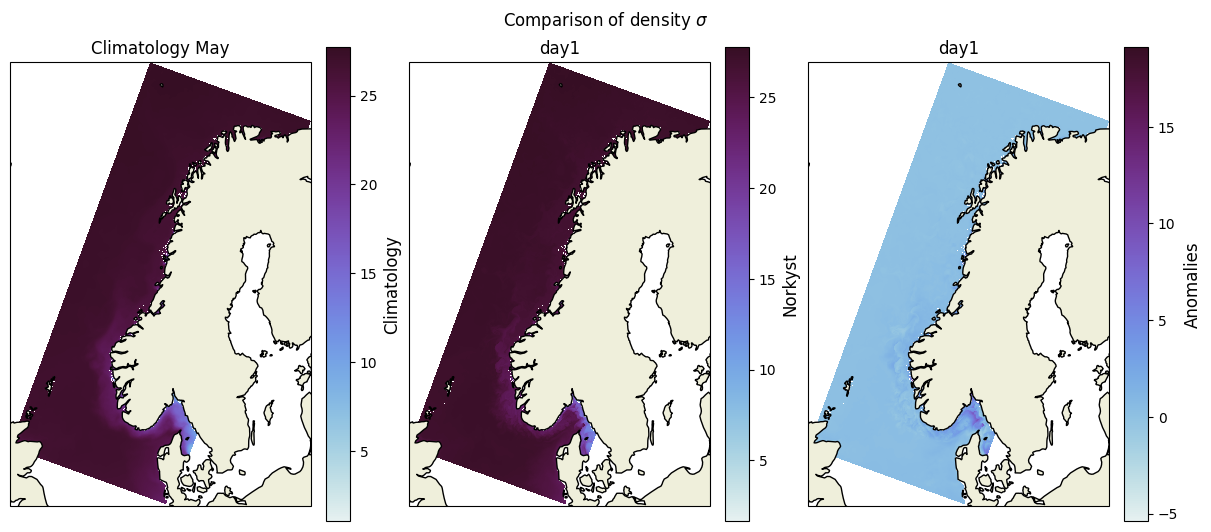

In [63]:
fig, axes = plt.subplots(1,3, figsize = (12, 10), layout = 'compressed', subplot_kw= { 'projection' : ccrs.NorthPolarStereo()})
lon = norkyst_1.lon.values
lat = norkyst_1.lat.values

#climatology
ax_clim = axes[0]
im1 = ax_clim.pcolormesh(lon, lat, density_sigma_clima, cmap = cmocean.cm.dense, transform = ccrs.PlateCarree())
ax_clim.set_title(f'Climatology May') 
ax_clim.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar1 = fig.colorbar(im1, ax=ax_clim, orientation = 'vertical')
cbar1.set_label('Climatology', fontsize = 12)

#norkyst
ax_norkyst = axes[1]
im2 = ax_norkyst.pcolormesh(lon, lat, density_sigma_nor, cmap = cmocean.cm.dense, transform = ccrs.PlateCarree())
ax_norkyst.set_title(f'{day}') 
ax_norkyst.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar2 = fig.colorbar(im2, ax=ax_norkyst, orientation = 'vertical')
cbar2.set_label('Norkyst', fontsize = 12)

#anomalies
ax_anomaly = axes[2]
im3 = axes[2].pcolormesh(lon, lat, anomalies_sigma, cmap = cmocean.cm.dense, transform = ccrs.PlateCarree())
ax_anomaly.set_title(f'{day}') 
ax_anomaly.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar2 = fig.colorbar(im3, ax=ax_anomaly, orientation = 'vertical')
cbar2.set_label('Anomalies', fontsize = 12)
for ax in [ax_clim, ax_norkyst, ax_anomaly]:
    ax.set_ylabel('Latitude')
    ax.set_xlabel('Longitude')
    
plt.suptitle(r'Comparison of density $\sigma$')
plt.show()


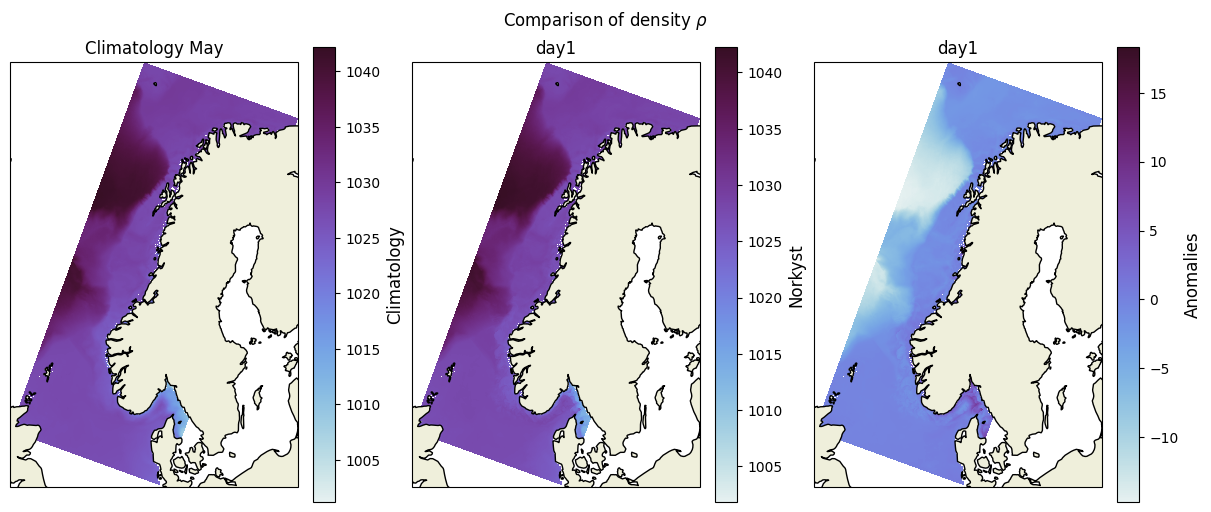

In [62]:
fig, axes = plt.subplots(1,3, figsize = (12, 10), layout = 'compressed', subplot_kw= { 'projection' : ccrs.NorthPolarStereo()})
lon = norkyst_1.lon.values
lat = norkyst_1.lat.values

#climatology
ax_clim = axes[0]
im1 = ax_clim.pcolormesh(lon, lat, density_rho_clima, cmap = cmocean.cm.dense, transform = ccrs.PlateCarree())
ax_clim.set_title(f'Climatology May') 
ax_clim.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar1 = fig.colorbar(im1, ax=ax_clim, orientation = 'vertical')
cbar1.set_label('Climatology', fontsize = 12)

#norkyst
ax_norkyst = axes[1]
im2 = ax_norkyst.pcolormesh(lon, lat, density_rho_nor, cmap = cmocean.cm.dense, transform = ccrs.PlateCarree())
ax_norkyst.set_title(f'{day}') 
ax_norkyst.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar2 = fig.colorbar(im2, ax=ax_norkyst, orientation = 'vertical')
cbar2.set_label('Norkyst', fontsize = 12)

#anomalies
ax_anomaly = axes[2]
im3 = axes[2].pcolormesh(lon, lat, anomalies_rho, cmap = cmocean.cm.dense, transform = ccrs.PlateCarree())
ax_anomaly.set_title(f'{day}') 
ax_anomaly.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = "black")
cbar2 = fig.colorbar(im3, ax=ax_anomaly, orientation = 'vertical')
cbar2.set_label('Anomalies', fontsize = 12)
for ax in [ax_clim, ax_norkyst, ax_anomaly]:
    ax.set_ylabel('Latitude')
    ax.set_xlabel('Longitude')
    
plt.suptitle(r'Comparison of density $\rho$')
plt.show()

In [64]:
import seaborn as sns

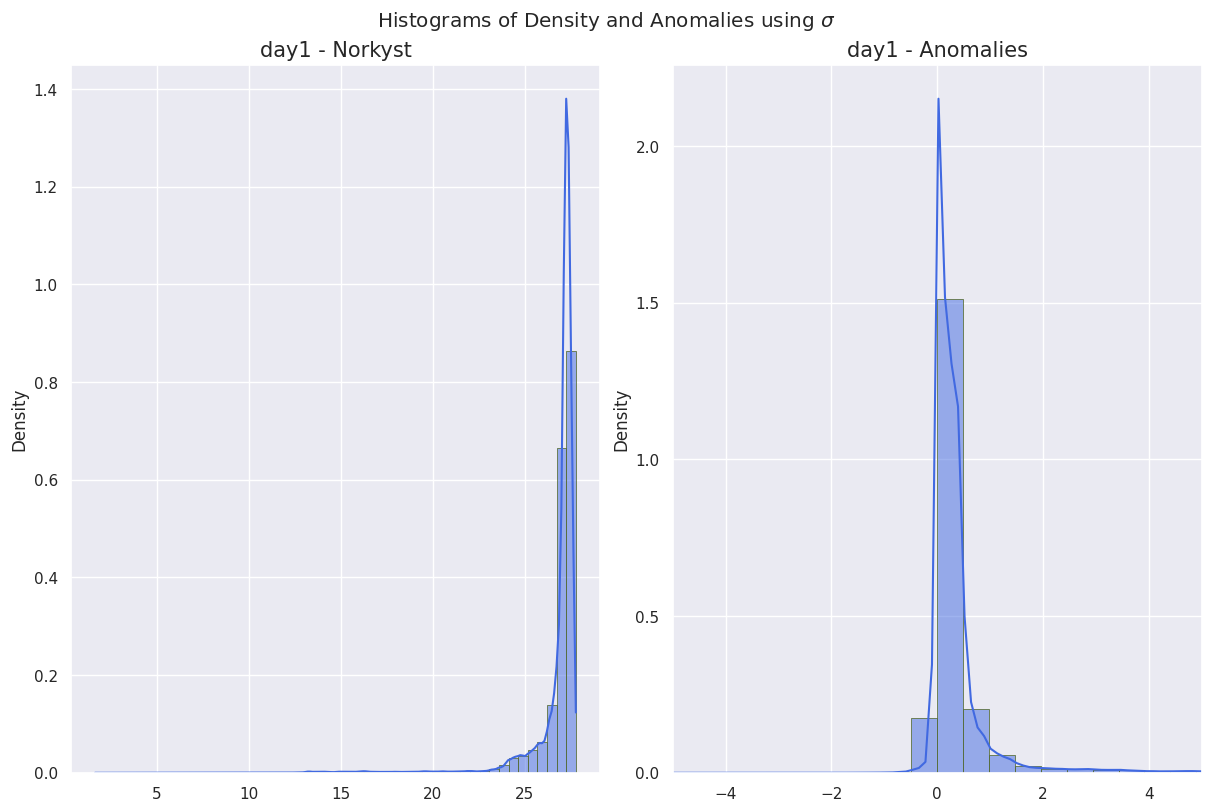

In [70]:
#now lets check the distribution of the density 
sns.set_theme(style='darkgrid')
columns_hist = 2 
fig, axes = plt.subplots(1, columns_hist, figsize = (12, 8), layout = 'compressed')

#remove nans 
norkyst_dens = density_sigma_nor[~np.isnan(density_sigma_nor)]
anomaly_dens = anomalies_sigma[~np.isnan(anomalies_sigma)]

#ravel
norkyst_d = norkyst_dens.ravel()
anomaly_d = anomaly_dens.ravel()

#im1 
ax_norkyst_hist = axes[0]
im1 = sns.histplot(norkyst_d, bins = 50, kde = True, ax = ax_norkyst_hist, stat = 'density', color = 'royalblue', edgecolor = 'darkolivegreen')
ax_norkyst_hist.set_title(f'{day} - Norkyst', fontsize = 15)

#im2
ax_anomalies = axes[1]
im1 = sns.histplot(anomaly_d, bins = 50, kde = True, ax = ax_anomalies, stat = 'density', color = 'royalblue', edgecolor = 'darkolivegreen')
ax_anomalies.set_title(f'{day} - Anomalies', fontsize = 15)
ax_anomalies.set_xlim(-5,5)

plt.suptitle(r'Histograms of Density and Anomalies using $\sigma$')
plt.show()



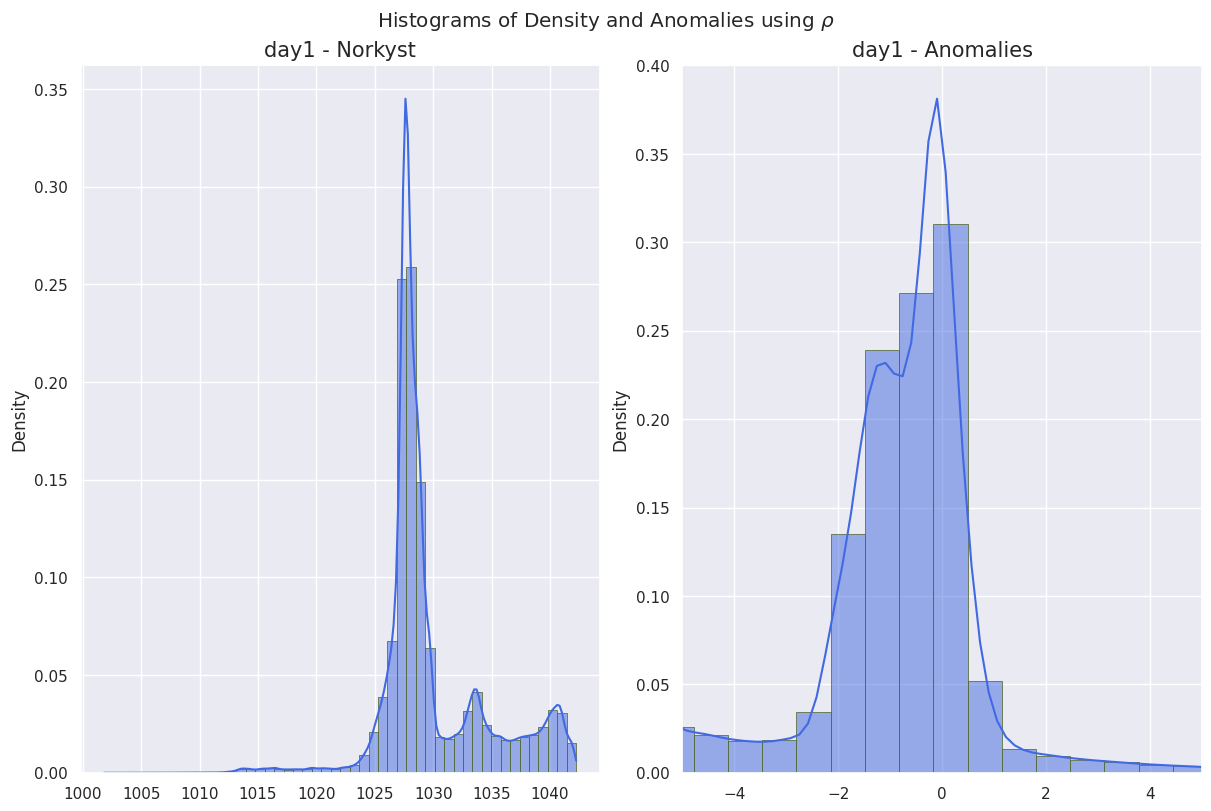

In [71]:
#now lets check the distribution of the density 
sns.set_theme(style='darkgrid')
columns_hist = 2 
fig, axes = plt.subplots(1, columns_hist, figsize = (12, 8), layout = 'compressed')

#remove nans 
norkyst_dens_r = density_rho_nor[~np.isnan(density_rho_nor)]
anomaly_dens_r = anomalies_rho[~np.isnan(anomalies_rho)]

#ravel
norkyst_d_r = norkyst_dens_r.ravel()
anomaly_d_r = anomaly_dens_r.ravel()

#im1 
ax_norkyst_hist = axes[0]
im1 = sns.histplot(norkyst_d_r, bins = 50, kde = True, ax = ax_norkyst_hist, stat = 'density', color = 'royalblue', edgecolor = 'darkolivegreen')
ax_norkyst_hist.set_title(f'{day} - Norkyst', fontsize = 15)

#im2
ax_anomalies = axes[1]
im1 = sns.histplot(anomaly_d_r, bins = 50, kde = True, ax = ax_anomalies, stat = 'density', color = 'royalblue', edgecolor = 'darkolivegreen')
ax_anomalies.set_title(f'{day} - Anomalies', fontsize = 15)
ax_anomalies.set_xlim(-5,5)

plt.suptitle(r'Histograms of Density and Anomalies using $\rho$')
plt.show()


In [73]:
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler

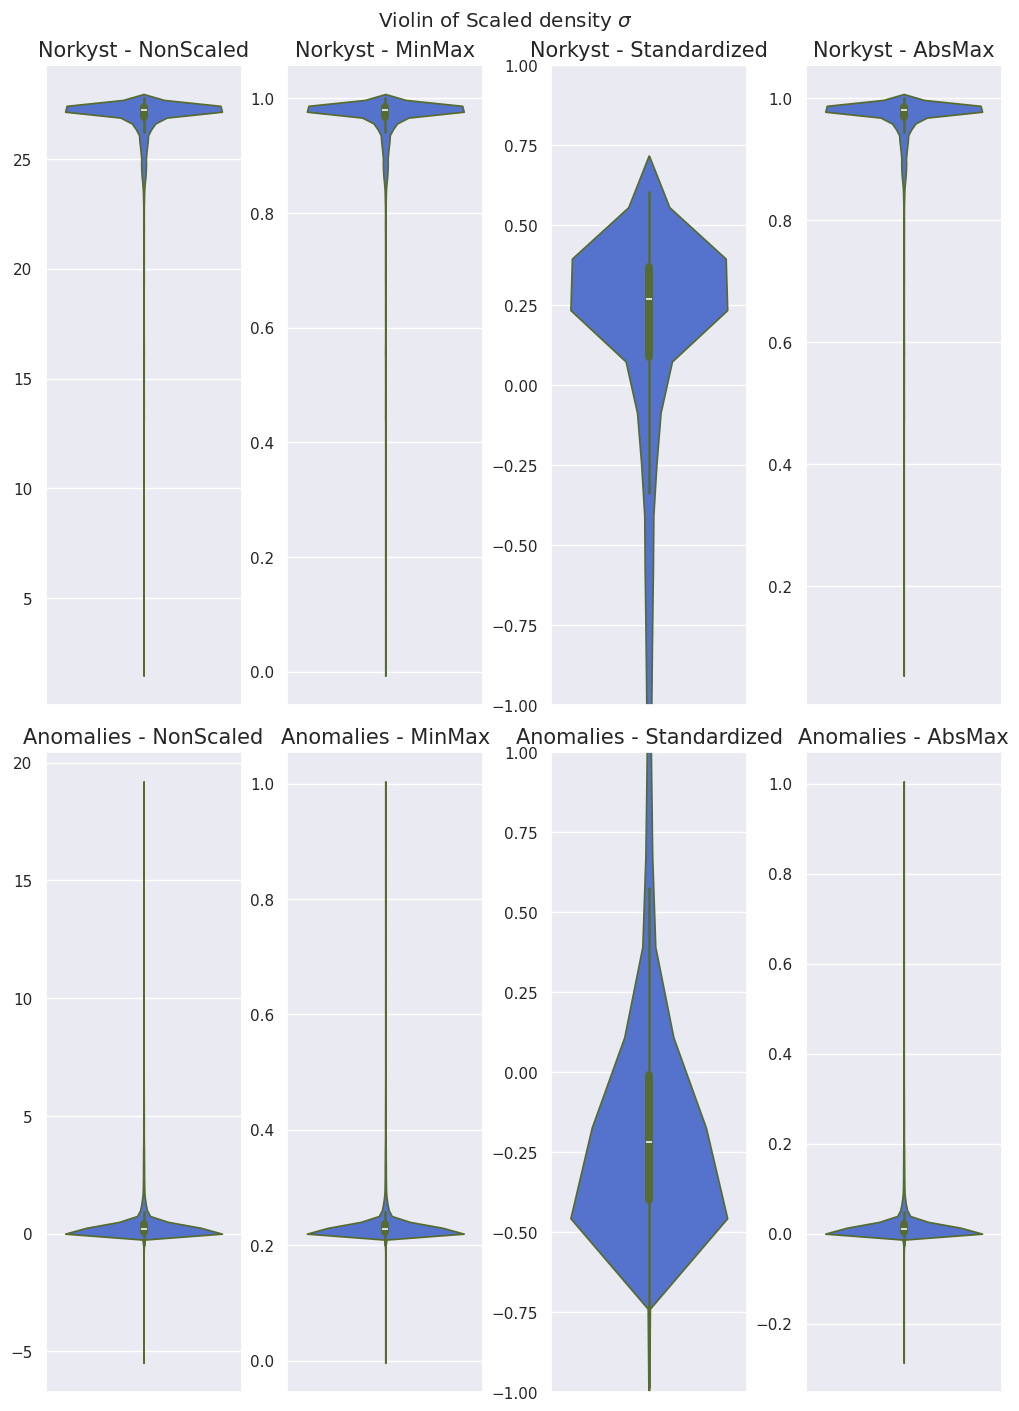

In [86]:
sns.set_theme(style='darkgrid')
columns_hist = 2 
fig, axes = plt.subplots(2, 4, figsize = (10, 14), layout = 'compressed')

#remove nans 
norkyst_dens = density_sigma_nor[~np.isnan(density_sigma_nor)]
anomaly_dens = anomalies_sigma[~np.isnan(anomalies_sigma)]

#ravel
norkyst_d = norkyst_dens.ravel()
anomaly_d = anomaly_dens.ravel()

#Employ the minmax scaler 
scaler = MinMaxScaler()
minmax_dens_n = scaler.fit_transform(norkyst_dens.reshape(-1,1)).ravel()
minmax_dens_a = scaler.fit_transform(anomaly_dens.reshape(-1,1)).ravel()

#Employ the minmax scaler 
scaler1 = StandardScaler()
normalized_dens_n = scaler1.fit_transform(norkyst_dens.reshape(-1,1)).ravel()
normalized_dens_a = scaler1.fit_transform(anomaly_dens.reshape(-1,1)).ravel()

scaler2 = MaxAbsScaler()
maxabs_dens_n = scaler2.fit_transform(norkyst_dens.reshape(-1,1)).ravel()
maxabs_dens_a= scaler2.fit_transform(anomaly_dens.reshape(-1, 1)).ravel()

#im1 
ax_norkyst_v = axes[0][0]
ax_norkyst_minmax = axes[0][1]
ax_norkyst_standardized = axes[0][2]
ax_norkyst_absmax = axes[0][3]
im1 = sns.violinplot(norkyst_d, ax = ax_norkyst_v, color = 'royalblue', edgecolor = 'darkolivegreen')
im2 = sns.violinplot(minmax_dens_n, ax = ax_norkyst_minmax, color = 'royalblue', edgecolor = 'darkolivegreen')
im3 = sns.violinplot(normalized_dens_n, ax = ax_norkyst_standardized, color = 'royalblue', edgecolor = 'darkolivegreen')
im4 = sns.violinplot(maxabs_dens_n, ax = ax_norkyst_absmax, color = 'royalblue', edgecolor = 'darkolivegreen')
ax_norkyst_v.set_title(f'Norkyst - NonScaled', fontsize = 15)
ax_norkyst_minmax.set_title(f'Norkyst - MinMax', fontsize = 15)
ax_norkyst_standardized.set_title(f'Norkyst - Standardized', fontsize = 15)
ax_norkyst_absmax.set_title(f'Norkyst - AbsMax', fontsize = 15)
ax_norkyst_standardized.set_ylim(-1,1)

#im2
ax_anomalies_v = axes[1][0]
ax_anomalies_minmax = axes[1][1]
ax_anomalies_standardized = axes[1][2]
ax_anomalies_absmax = axes[1][3]
im1 = sns.violinplot(anomaly_d, ax = ax_anomalies_v, color = 'royalblue', edgecolor = 'darkolivegreen')
im2 = sns.violinplot(minmax_dens_a, ax = ax_anomalies_minmax, color = 'royalblue', edgecolor = 'darkolivegreen')
im3 = sns.violinplot(normalized_dens_a, ax = ax_anomalies_standardized, color = 'royalblue', edgecolor = 'darkolivegreen')
im4 = sns.violinplot(maxabs_dens_a, ax = ax_anomalies_absmax, color = 'royalblue', edgecolor = 'darkolivegreen')
ax_anomalies_v.set_title(f'Anomalies - NonScaled', fontsize = 15)
ax_anomalies_minmax.set_title(f'Anomalies - MinMax', fontsize = 15)
ax_anomalies_standardized.set_title(f'Anomalies - Standardized', fontsize = 15)
ax_anomalies_absmax.set_title(f'Anomalies - AbsMax', fontsize = 15)
ax_anomalies_standardized.set_ylim(-1,1)

plt.suptitle(r'Violin of Scaled density $\sigma$')
plt.show()
